<a href="https://colab.research.google.com/github/Ep1cMax/University_4th_term/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9612.2_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)

**Ответ**: я решил выбрать Раменское, т. к., не смотря на свой небольшой размер в городе всё ещё присутствуют места, которые могут подойти практически для любого бизнеса.


   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)

   **Ответ**: я решил выбрать точки выдачи заказов Ozon, так как не смотря на достаточно большое количество точек выдачи в городе, всё равно присутствуют места, где близко к жилой или торговой зоне отсутсвует точка.

   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

   **Ответ**: ПВЗ Ozon интересны для анализа того, например, где лучше всего будет открыть ещё один ПВЗ, как часто пользуются или, например, уже имеющимися ПВЗ.


2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса

   **Ответ**:
- **Локация**. Наиболее важный пункт, насколько удобно добраться до ПВЗ, какой размер территории он может покрыть
- **Конкуренция**. Плотность пунктов в жилом массиве, необходимо выбирать локации, где поблизости нет других ПВЗ того же или конкурирующих маркетплейсов.
- **Трафик**. Находятся ли поблизости остановки, станции метро; крупные здания по типу школ, садов, офисов и т.д.
- **Площадь**. Большая площадь помещения может быть более благоприятной для ПВЗ, так как позволяет создавать более крупный склад для хранения товаров
- **Наличие поблизости парковок**. Возможно, некоторым людям всегда удобнее будет приезжать к ПВЗ. Также это позволяет людям забирать более крупные заказы на машине

   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать

**Ответ**:

- *Локация*:

      building:apartments, residential
      landuse:residential
      addr:housenumber: * (подсчет количества адресов в полигоне)

- *Конкуренция*:    
  - Прямые конкуренты (ПВЗ):
        
        shop:outpost
        amenity:parcel_locker (постаматы)
        brand:Ozon, Wildberries, Yandex Market (или name:...)
  - Смежные конкуренты (почта/логистика):

        amenity:post_office
        shop:courier

- *Трафик*:

      shop:supermarket, mall
      public_transport:stop_position
      railway:station
      amenity:school, kindergarten, marketplace
      office:*

- *Площадь*:

  к сожалению, в OSM подобные данные являются редкостью, однако можно попробовать следующие теги:

        rooms:* (количество комнат; для ПВЗ желательно ≥ 2: зал выдачи + склад)
        indoor:room + room:storage (наличие выделенного склада внутри)

- *Наличие поблизости парковок*:

        amenity:parking
        parking:street_side, lane
        access:customers, public
        highway:living_street
        fee:no

   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

|Фактор|Тэг|
|-|-|
|Локация|building:apartments, residential<br>landuse:residential|
|Конкуренция|shop:outpost<br>amenity:parcel_locker<br>brand:Ozon, Wildberries, Yandex Market|
|Трафик|shop:supermarket,mall<br>amenity:marketplace<br>public_transport:stop_position<br>railway:station<br>amenity:school, kindergarten<br>office:*|
|Площадь|rooms=*<br>indoor:room + room:storage |
|Наличие парковок|amenity:parking<br>parking:street_side, lane <br>access:public<br>highway:living_street<br>fee:no|

3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала

In [40]:
!pip install osmnx geopandas leafmap mapclassify h3pandas h3~=3.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import leafmap
import osmnx as ox
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
import h3
import h3pandas

   - Определите необходимую область интереса (ROI) с помощью интерактивной карты


In [ ]:
# не запускать это, а то сбросится выделенный прямоугольник
# m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
# m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [ ]:
# bbox = m.user_roi_bounds()
# print(m.center)
# print(bbox)

   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [41]:
ozon_gdf = ox.features_from_place("Раменское", tags={'name':'Ozon', 'brand':'Ozon'})
ozon_gdf

geometry brand brand:wikidata  \
element id                                                            
node    9076606484   POINT (38.20212 55.57386)  Ozon       Q2365235   
        9076607510    POINT (38.20843 55.5748)  Ozon       Q2365235   
        9076607808   POINT (38.25352 55.59477)  Ozon       Q2365235   
        9076607998   POINT (38.21496 55.57886)  Ozon       Q2365235   
        9076609300   POINT (38.21195 55.56921)  Ozon       Q2365235   
...                                        ...   ...            ...   
        11806975710  POINT (38.26463 55.55588)  Ozon       Q2365235   
        12317968510  POINT (38.26964 55.57504)  Ozon       Q2365235   
        13367869770  POINT (38.22664 55.56942)   NaN            NaN   
        13739964117  POINT (38.28558 55.57703)  Ozon       Q2365235   
        13917360603  POINT (38.27028 55.57043)  Ozon       Q2365235   

                    brand:wikipedia                  contact:facebook  \
element id                                                              
node    9076606484       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607510       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607808       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607998       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076609300       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
...                             ...                               ...   
        11806975710      ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        12317968510      ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        13367869770             NaN                               NaN   
        13739964117             NaN                               NaN   
        13917360603             NaN                               NaN   

                                    contact:instagram   contact:phone  \
element id                                                              
node    9076606484   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607510   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607808   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607998   https://www.instagram.com/ozonru  +7 495 2321000   
        9076609300   https://www.instagram.com/ozonru  +7 495 2321000   
...                                               ...             ...   
        11806975710  https://www.instagram.com/ozonru  +7 495 2321000   
        12317968510  https://www.instagram.com/ozonru  +7 495 2321000   
        13367869770                               NaN  +7 495 2321000   
        13739964117                               NaN             NaN   
        13917360603                               NaN             NaN   

                                 contact:twitter           contact:vk  \
element id                                                              
node    9076606484   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607510   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607808   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607998   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076609300   https://twitter.com/Ozon_ru  https://vk.com/ozon   
...                                          ...                  ...   
        11806975710  https://twitter.com/Ozon_ru  https://vk.com/ozon   
        12317968510  https://twitter.com/Ozon_ru  https://vk.com/ozon   
        13367869770                          NaN                  NaN   
        13739964117                          NaN                  NaN   
        13917360603                          NaN                  NaN   

                          contact:website  name      opening_hours     shop  \
element id                                                                    
node    9076606484    https://www.ozon.ru  Ozon  Mo-Su 10:00-22:00  outpost   
        9076607510   https:

In [42]:
m = leafmap.Map(basemap='CartoDB.Positron')
bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [37.444, 55.2955, 37.6569, 55.496]
    print(f"Область не выбрана. Используем значение по умолчанию: {bbox}")
m2 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')
m2.add_gdf(ozon_gdf, layer_name='OZON Location', info_mode='on_click')

m2

Область не выбрана. Используем значение по умолчанию: [37.444, 55.2955, 37.6569, 55.496]


Map(center=[55.39575, 37.55045], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа

In [44]:
res = 9
place_name = 'Раменское'
crs_proj = "EPSG:3857"

   - Покройте территорию гексагональной сеткой выбранного разрешения

In [45]:
# Получаем полигон территории
area_gdf = ox.geocode_to_gdf(place_name).to_crs("EPSG:4326")
bbox = area_gdf.total_bounds

# Генерируем H3-индексы
bbox_poly = box(*bbox)
h3_ids = list(h3.polyfill_geojson(bbox_poly.__geo_interface__, res))

# Создаём геометрии гексагонов из индексов
h3_geoms = [Polygon(h3.h3_to_geo_boundary(idx, geo_json=True)) for idx in h3_ids]

h3_gdf = gpd.GeoDataFrame({'h3_index': h3_ids, 'geometry': h3_geoms}, crs="EPSG:4326")

# Обрезаем по реальной границе города и переводим в метрическую проекцию
h3_gdf = h3_gdf[h3_gdf.intersects(area_gdf.unary_union)].reset_index(drop=True)
h3_gdf = h3_gdf.to_crs(crs_proj)

# Переводим сетку в EPSG:4326 (широта/долгота)
h3_gdf_viz = h3_gdf.to_crs("EPSG:4326")

m3 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m3.add_gdf(
    h3_gdf_viz,
    layer_name="H3 Сетка (res 10)",
    info_mode="on_hover",
    style={
        "stroke": True,
        "color": "#3388ff",
        "weight": 1.5,
        "fillOpacity": 0.15,
        "fillColor": "#3388ff"
    }
)

m3

Map(center=[np.float64(55.54351235), np.float64(38.258448200000004)], controls=(ZoomControl(options=['position…

- Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса

**Ответ**: выбранное разрешение (9, площадь ячейки=~0.11 км², ребро ~174 м) предоставляет баланс между производительностью и детализацией, затрагивает достаточно оптимальную площадь для данного анализа - она и не слишком маленькая/точная, и не слишком большая/распространенная

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)

**Ответ**:
- Радиус 300 м (~5 мин. пешком): оценка доступности вблизи жилых домой, для более быстрого доступа к ПВЗ
- Радиус 600 м (~10 мин. пешком): оценка доступности в зонах, где затруднительно где-либо расположить ПВЗ, но всё ещё в относительной близости к жилым домам


Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки

In [46]:
#1
own_buildings_nearby_gdf = ox.features_from_place(place_name, tags={'name':'Ozon', 'brand':'Ozon'})
own_buildings_nearby_gdf = own_buildings_nearby_gdf.to_crs(crs_proj)
#2
competitors_gdf = ox.features_from_place(place_name, tags={'brand':['Wildberries', 'Yandex.market', 'Yandex Market'],
                                                           'name':['Wildberries', 'Yandex.market', 'Yandex Market'],
                                                           'amenity':'post_office', 'shop':'courier'})
competitors_gdf = competitors_gdf.to_crs(crs_proj)
#3
shops_nearby_gdf = ox.features_from_place(place_name, tags={'shop':['supermarket', 'mall'], 'amenity':'marketplace'})
shops_nearby_gdf = shops_nearby_gdf.to_crs(crs_proj)
#4
houses_gdf = ox.features_from_place(place_name, tags={'building':['apartments', 'residential']})
houses_gdf = houses_gdf.to_crs(crs_proj)
#5
public_transport_gdf = ox.features_from_place(place_name, tags={'public_transport':'stop_position', 'railway':'station'})
public_transport_gdf = public_transport_gdf.to_crs(crs_proj)
#6
public_transport_nearby_gdf = ox.features_from_place(place_name, tags={'public_transport':'stop_position', 'railway':'station'})
public_transport_nearby_gdf = public_transport_nearby_gdf.to_crs(crs_proj)
#7
parcel_locker_gdf = ox.features_from_place(place_name, tags={'amenity':'parcel_locker'})
parcel_locker_gdf = parcel_locker_gdf.to_crs(crs_proj)
#8
parcel_locker_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':'parcel_locker'})
parcel_locker_nearby_gdf = parcel_locker_nearby_gdf.to_crs(crs_proj)
#9
buildings_gdf = ox.features_from_place(place_name, tags={'amenity':['school', 'kindergarten'], 'office':'*'})
buildings_gdf = buildings_gdf.to_crs(crs_proj)
#10
buildings_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':['school', 'kindergarten'], 'office':'*'})
buildings_nearby_gdf = buildings_nearby_gdf.to_crs(crs_proj)

**Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

In [47]:
#1
landuse_gdf = ox.features_from_place(place_name, tags={"landuse": "residential"})
landuse_gdf = landuse_gdf.to_crs(crs_proj)
#2
parking_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':'parking', 'parking':['street_side', 'lane']})
parking_nearby_gdf = parking_nearby_gdf.to_crs(crs_proj)

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку

In [48]:
def analyze_h3_cell(geom):
    buffer_300m = geom.buffer(300)
    buffer_600m = geom.buffer(600)
    own_buildings_nearby = own_buildings_nearby_gdf[own_buildings_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    competitors = competitors_gdf[competitors_gdf.geometry.intersects(buffer_600m)].shape[0]
    shops_nearby = shops_nearby_gdf[shops_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    houses = houses_gdf[houses_gdf.geometry.intersects(buffer_600m)].shape[0]
    public_transport = public_transport_gdf[public_transport_gdf.geometry.intersects(buffer_600m)].shape[0]
    public_transport_nearby = public_transport_nearby_gdf[public_transport_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    parcel_locker = parcel_locker_gdf[parcel_locker_gdf.geometry.intersects(buffer_600m)].shape[0]
    parcel_locker_nearby = parcel_locker_nearby_gdf[parcel_locker_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    buildings = buildings_gdf[buildings_gdf.geometry.intersects(buffer_600m)].shape[0]
    buildings_nearby = buildings_nearby_gdf[buildings_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    landuse = landuse_gdf[landuse_gdf.geometry.intersects(buffer_600m)].shape[0]
    parking_nearby = parking_nearby_gdf[parking_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    return own_buildings_nearby, competitors, shops_nearby, houses, public_transport, public_transport_nearby, parcel_locker, parcel_locker_nearby, buildings, buildings_nearby, landuse, parking_nearby

In [51]:
from sklearn.preprocessing import MinMaxScaler

features = ['own_buildings_nearby', 'competitors', 'shops_nearby', 'houses', 'public_transport',
            'public_transport_nearby', 'parcel_locker', 'parcel_locker_nearby',
            'buildings', 'buildings_nearby', 'landuse', 'parking_nearby']
scaler = MinMaxScaler()
main_gdf = h3_gdf.copy()
main_gdf[features] = main_gdf.geometry.apply(
    lambda geom: pd.Series(analyze_h3_cell(geom))
)
main_gdf[features] = scaler.fit_transform(main_gdf[features])

   - Исследуйте корреляции между признаками

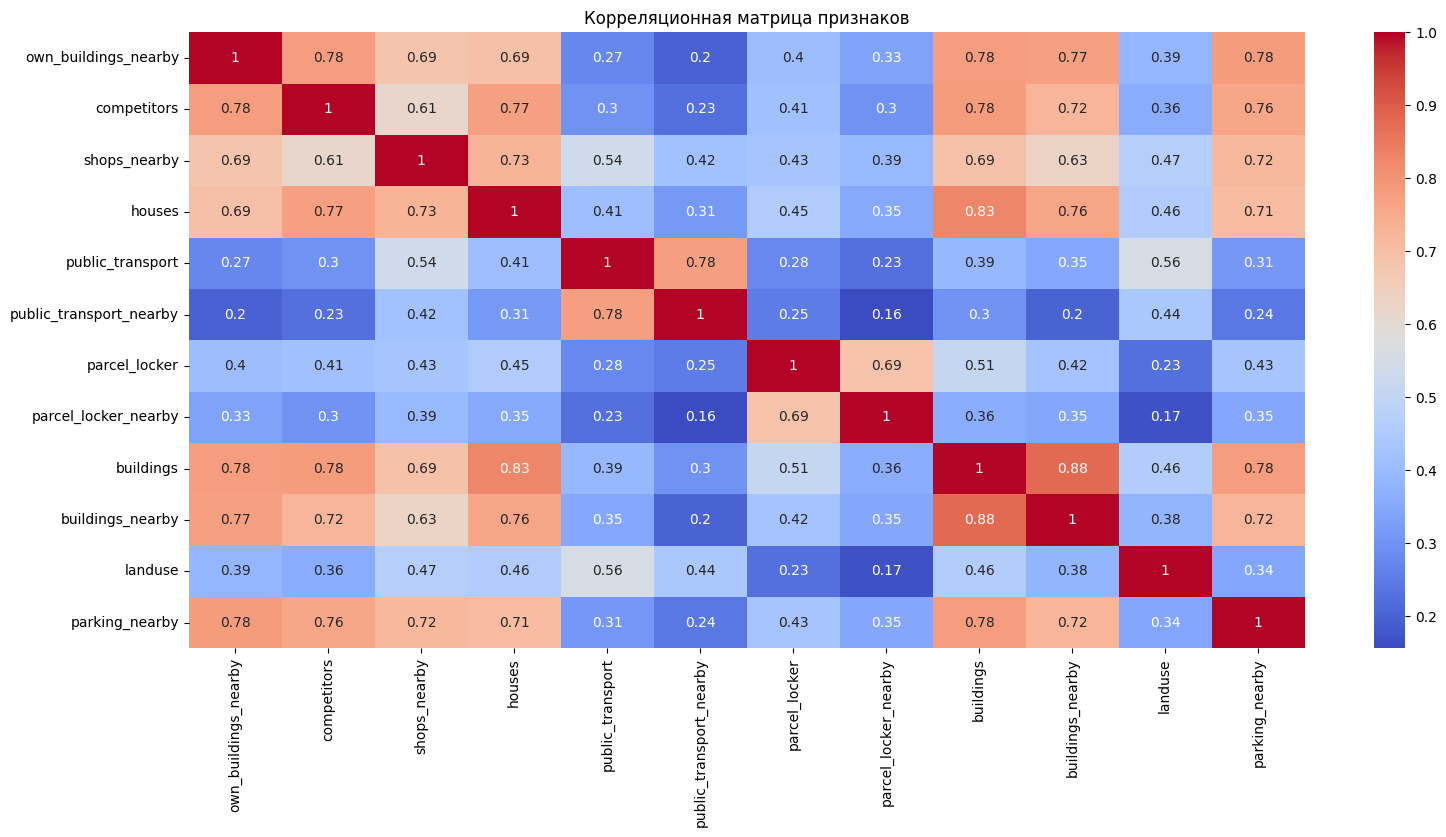

In [52]:
corr_mat = main_gdf[features].corr()
plt.figure(figsize=(18, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

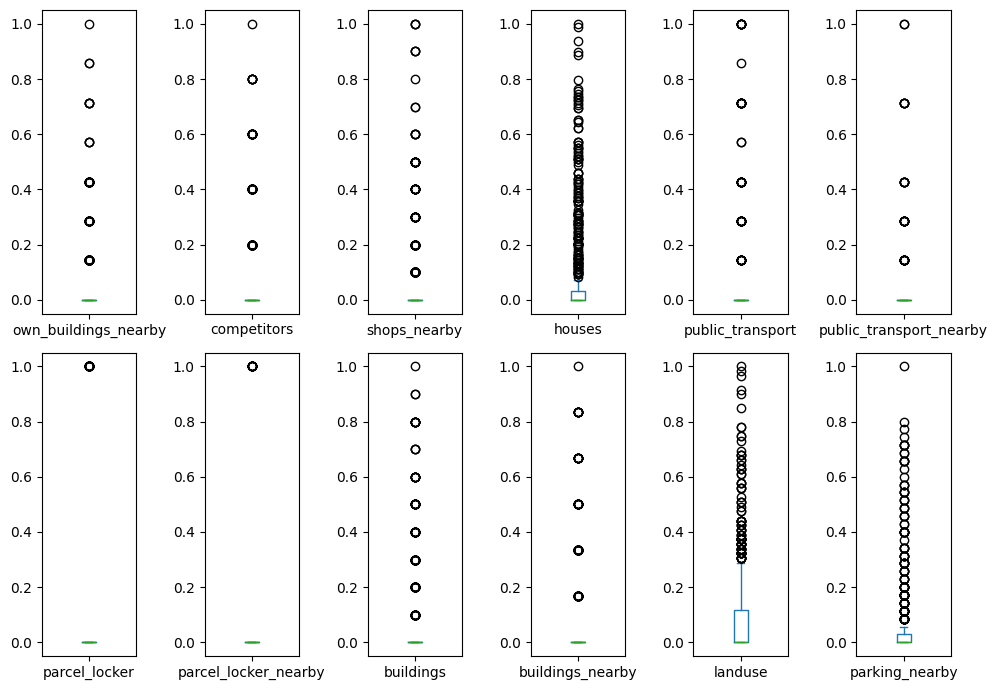

In [53]:
main_gdf[features].plot(kind='box', subplots=True, layout=(2, 6), figsize=(10, 7))
plt.tight_layout()

Подобные выбросы ожидаемы, т.к. изучались участки как и с плотными жилыми районами, так и такие, что находятся в промышленных или малонаселенных участках. Пропусков в данных нет, поэтому, не будем никак обрабатывать данные

### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)


Будем считать следующим образом:

Вычитать баллы будем за наличие поблизости уже существующих своих ПВЗ (наибольший штраф) и чуть меньше за наличие поблизости конкурентов

За остальное действуем следующим образом:

- в "двойных" признаках (которые учитываются и на 300, и на 600 м) будем считать больше баллов за ближайщие объекты, вычитывать эти объекты из числа тех, что находятся дальше, и назначать меньше за дальние объекты

- больше всего баллов будем назначать за наличие жилых домов, транспортных остановок и иных зданий (детсадов, офисов, школ и т.д.) поблизости. За остальные - меньше

In [55]:
main_gdf['index_score'] = (
    (main_gdf['own_buildings_nearby'] * -0.7) +
    (main_gdf['competitors'] * -0.15) +
    (main_gdf['shops_nearby']* 0.15) +
    (main_gdf['houses'] * 0.2) +
    ((main_gdf['public_transport']-main_gdf['public_transport_nearby'])* 0.03) +
    (main_gdf['public_transport_nearby'] * 0.1) +
    ((main_gdf['parcel_locker']-main_gdf['parcel_locker_nearby'])* 0.03) +
    (main_gdf['parcel_locker_nearby'] * 0.15) +
    ((main_gdf['buildings'] - main_gdf['buildings_nearby']) * 0.1) +
    (main_gdf['buildings_nearby'] * 0.22) +
    ((main_gdf['landuse']-main_gdf['houses']) * 0.05) +
    (main_gdf['parking_nearby'] * 0.15)
    )*10
main_gdf['index_score'] = scaler.fit_transform(pd.DataFrame(main_gdf['index_score']))

   - Исследуйте распределение целевой переменной и оцените её сбалансированность

In [56]:
main_gdf['index_score'].describe()

,index_score
count,752.000000
mean,0.575878
std,0.079200
min,0.000000
25%,0.562793
50%,0.562793
75%,0.573392
max,1.000000


<Axes: >

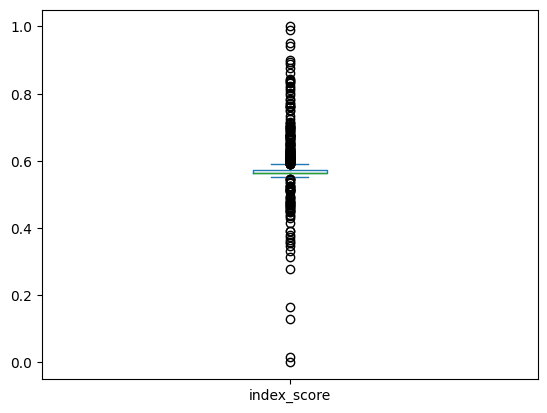

In [57]:
main_gdf['index_score'].plot(kind='box')

In [58]:
# Создаем карту
map_result = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=12, basemap='CartoDB.Positron')

# Добавляем H3 ячейки
map_result.add_data(
    main_gdf,
    column="index_score",
    cmap="OrRd",
    legend_title="index_score",
    k=20,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    }
)

# Отображаем карту
map_result

Map(center=[np.float64(55.54351235), np.float64(38.258448200000004)], controls=(ZoomControl(options=['position…

   - При необходимости, предложите стратегию работы с несбалансированными данными

Необходимости не вижу, как уже описывал ранее, подобные выбросы и возможная несбалансированность ожидаемы, так как работаем с различными районами города

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации

In [59]:
X = main_gdf[features].copy()
y = main_gdf['index_score'].copy()

X_df = pd.DataFrame(X, columns=features)
X_df.index = main_gdf.index
y.index = main_gdf.index

print("Размерность набора данных:", X.shape)
X_df.head(10)

Размерность набора данных: (752, 12)


,own_buildings_nearby,competitors,shops_nearby,houses,public_transport,public_transport_nearby,parcel_locker,parcel_locker_nearby,buildings,buildings_nearby,landuse,parking_nearby
0,0.142857,0.0,0.3,0.306122,0.285714,0.0,0.0,0.0,0.2,0.333333,0.915254,0.085714
1,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
5,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
6,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
7,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.050847,0.000000
8,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
9,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [60]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.4, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

   - Проведите оценку важности признаков для каждой модели

<Axes: title={'center': 'Важности признаков'}>

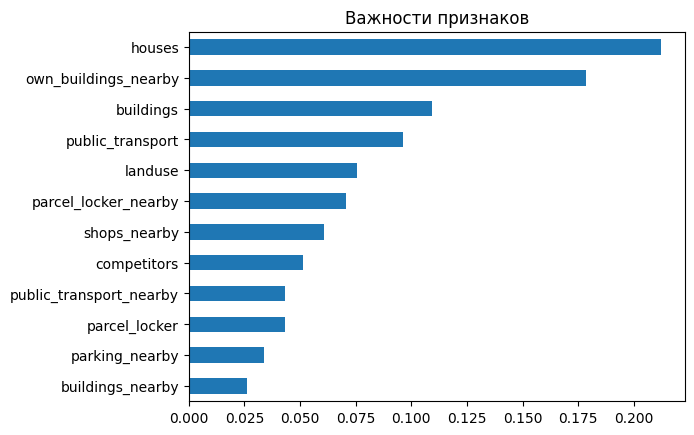

In [61]:
feat_imp = pd.Series(rf.feature_importances_, index=features)
feat_imp.sort_values().plot(kind='barh', title='Важности признаков')

<Axes: title={'center': 'Важности признаков (без own_buildings_nearby)'}>

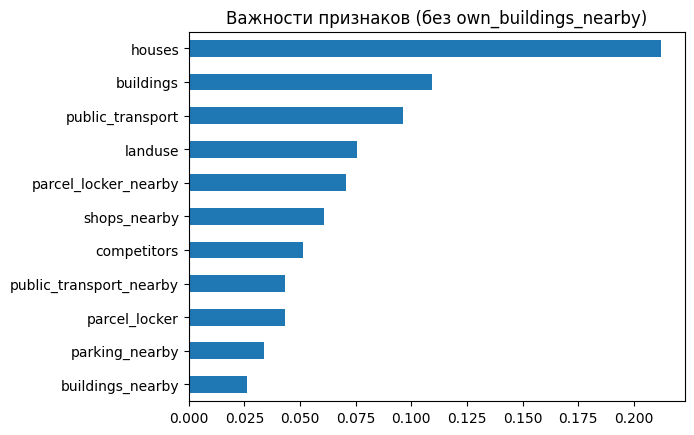

In [62]:
feat2= ['competitors', 'shops_nearby', 'houses', 'public_transport',
        'public_transport_nearby', 'parcel_locker', 'parcel_locker_nearby',
        'buildings', 'buildings_nearby', 'landuse', 'parking_nearby']
feat_imp[feat2].sort_values().plot(kind='barh', title='Важности признаков (без own_buildings_nearby)')

   - Сравните модели по метрикам качества и выберите наилучшую

In [63]:
results = []

r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test,rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
results.append({'Model': 'Random Forest', 'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf})


r2_gb = r2_score(y_test, gb_pred)
mae_gb = mean_absolute_error(y_test, gb_pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, gb_pred))
results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'MAE': mae_gb, 'RMSE': rmse_gb})

pd.DataFrame(results).sort_values('R2', ascending=False)

,Model,R2,MAE,RMSE
1,Gradient Boosting,0.694577,0.014230,0.048026
0,Random Forest,0.579106,0.016444,0.056379


   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

In [64]:
from sklearn.model_selection import GridSearchCV

n_estimators = [int(x) for x in range(50, 251, 10)]
learning_rate = np.arange(0.1, 2.0, 0.2)
max_depth = [int(x) for x in range(1, 8)]
max_depth.append(None)

param_grid = {
    'n_estimators': n_estimators
}

param2_grid = {
    'n_estimators': n_estimators,
    'learning_rate': learning_rate,
    'max_depth': max_depth
}

rf_cv = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)
rf_cv.fit(X_train, y_train)
gb_cv = GridSearchCV(estimator=gb, param_grid=param2_grid, cv=5, verbose=1, n_jobs=-1)
gb_cv.fit(X_train, y_train)

best_params_rf = rf_cv.best_params_
best_model_rf = rf_cv.best_estimator_
r2_best_rf = r2_score(y_test, best_model_rf.predict(X_test))

best_params_gb = gb_cv.best_params_
best_model_gb = gb_cv.best_estimator_
r2_best_gb = r2_score(y_test, best_model_gb.predict(X_test))

print(f"Лучшие параметры Random Forest: {best_params_rf}; R2: {r2_best_rf}")
print(f"Лучшие параметры Gradient Boosting: {best_params_gb}; R2: {r2_best_gb}")

Fitting 5 folds for each of 21 candidates, totalling 105 fits
Fitting 5 folds for each of 1680 candidates, totalling 8400 fits
Лучшие параметры Random Forest: {'n_estimators': 50}; R2: 0.56891174686667
Лучшие параметры Gradient Boosting: {'learning_rate': np.float64(1.3000000000000003), 'max_depth': 1, 'n_estimators': 240}; R2: 0.9657805504976847


3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам

Сначала определим оптимальное число k, далее применим KMeans++, DBSCAN/HDBSCAN, Agglomerative


   - Определите оптимальное число кластеров с помощью метода локтя или силуэта

In [65]:
%%capture
!pip install kneed

Оценка для k=2...
Оценка для k=3...
Оценка для k=4...
Оценка для k=5...
Оценка для k=6...
Оценка для k=7...
Оценка для k=8...
Оценка для k=9...
Оценка для k=10...
Оценка для k=11...
Оценка для k=12...


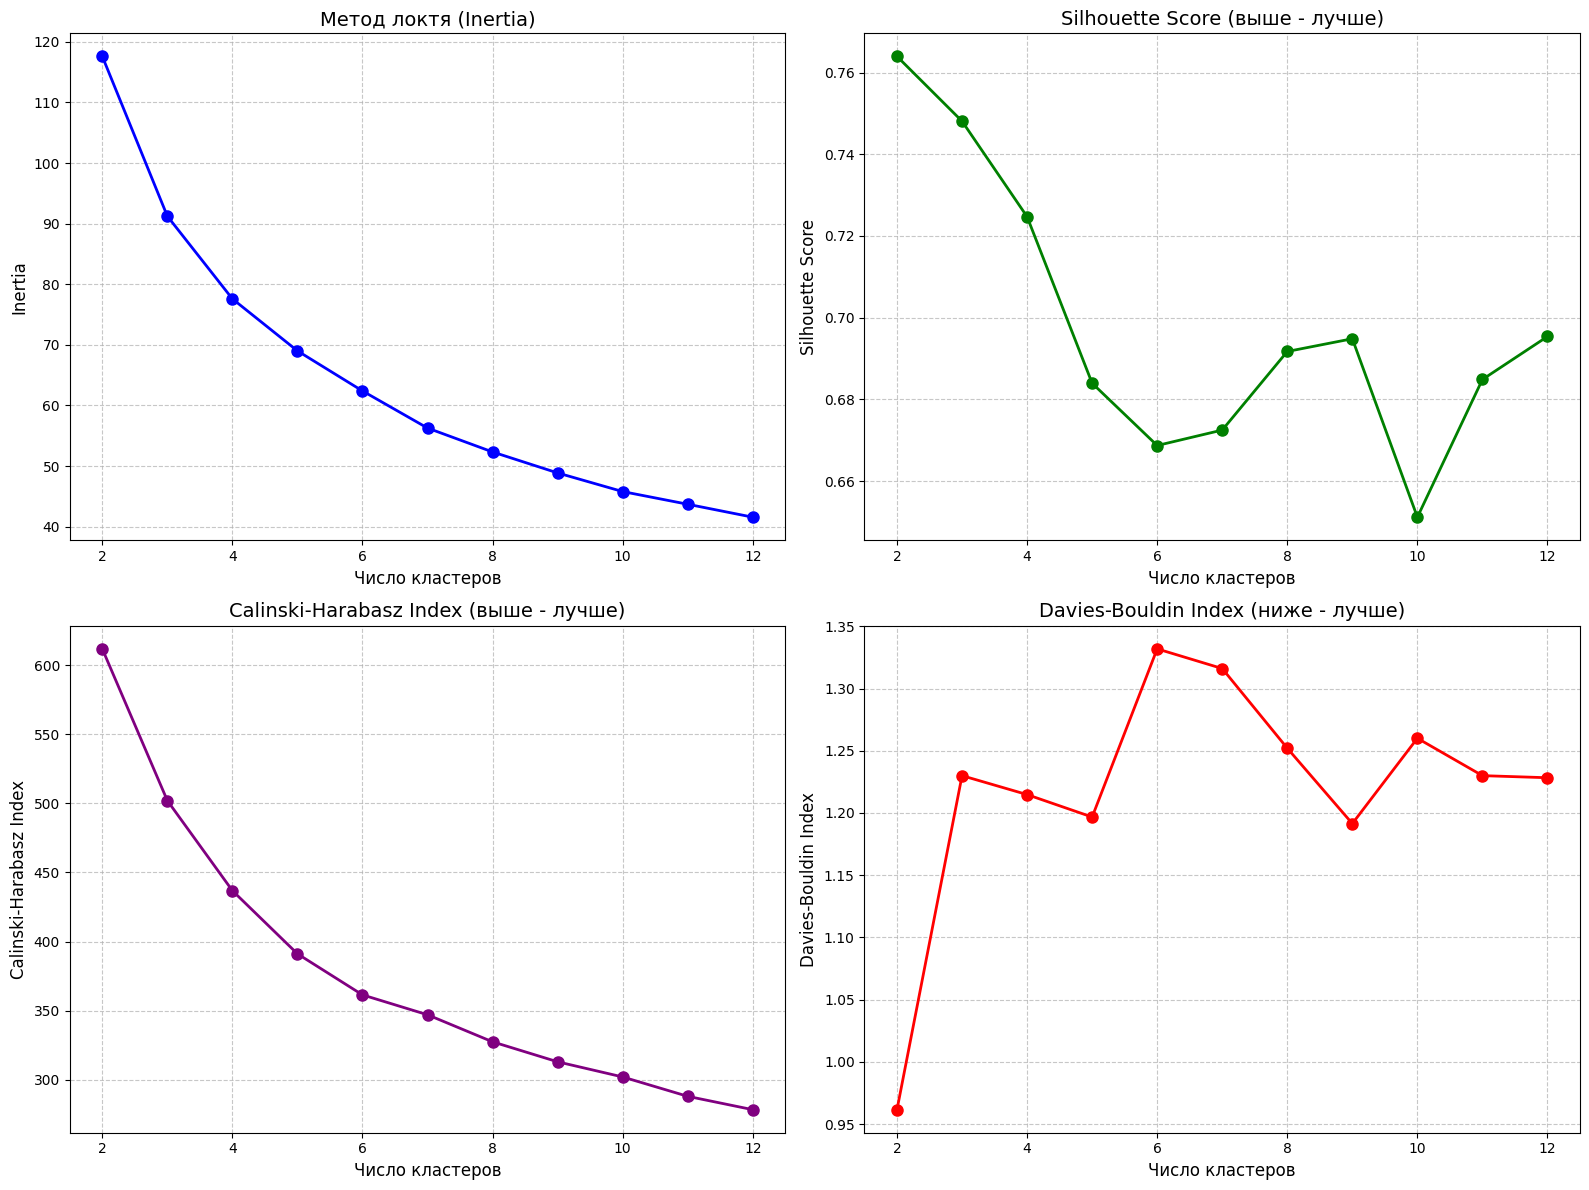


Оптимальное число кластеров по разным метрикам:
Метод локтя (Inertia): 5
Silhouette Score: 2
Calinski-Harabasz Index: 2
Davies-Bouldin Index: 2

Таблица со значениями метрик:


,Число кластеров,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,117.598052,0.763984,611.869741,0.961565
1,3,91.235806,0.748111,502.018209,1.229987
2,4,77.592932,0.724723,436.838065,1.214768
3,5,69.011645,0.683946,391.096735,1.196721
4,6,62.399431,0.668691,361.378625,1.331857
5,7,56.277396,0.672477,346.968438,1.316053
6,8,52.333962,0.691719,327.390614,1.252029
7,9,48.872869,0.694837,312.918814,1.191449
8,10,45.799409,0.651143,301.948985,1.260027
9,11,43.706757,0.684863,287.929584,1.229988


In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

def find_optimal_clusters(X, max_k=8):
    """
    Определение оптимального числа кластеров с помощью различных метрик
    """
    # Метрики для оценки качества кластеризации
    inertias = []  # Для метода локтя
    silhouette_scores = []  # Silhouette Score
    calinski_scores = []  # Calinski-Harabasz Index
    davies_scores = []  # Davies-Bouldin Index

    # Вычисляем значения метрик для разного числа кластеров
    k_range = range(2, max_k + 1)
    for k in k_range:
        print(f"Оценка для k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)

        labels = kmeans.labels_
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))

    # Визуализация результатов
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Метод локтя (Inertia)
    axes[0, 0].plot(k_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 0].set_ylabel('Inertia', fontsize=12)
    axes[0, 0].set_title('Метод локтя (Inertia)', fontsize=14)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Silhouette Score (чем выше, тем лучше)
    axes[0, 1].plot(k_range, silhouette_scores, 'o-', color='green', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
    axes[0, 1].set_title('Silhouette Score (выше - лучше)', fontsize=14)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Calinski-Harabasz Index (чем выше, тем лучше)
    axes[1, 0].plot(k_range, calinski_scores, 'o-', color='purple', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=12)
    axes[1, 0].set_title('Calinski-Harabasz Index (выше - лучше)', fontsize=14)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Davies-Bouldin Index (чем ниже, тем лучше)
    axes[1, 1].plot(k_range, davies_scores, 'o-', color='red', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[1, 1].set_title('Davies-Bouldin Index (ниже - лучше)', fontsize=14)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Находим оптимальное число кластеров по разным метрикам

    # Метод локтя (Inertia)
    kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
    optimal_k_inertia = kl.elbow if kl.elbow is not None else "Не определено"

    # Silhouette Score (максимальное значение)
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

    # Calinski-Harabasz (максимальное значение)
    optimal_k_calinski = k_range[np.argmax(calinski_scores)]

    # Davies-Bouldin (минимальное значение)
    optimal_k_davies = k_range[np.argmin(davies_scores)]

    print("\nОптимальное число кластеров по разным метрикам:")
    print(f"Метод локтя (Inertia): {optimal_k_inertia}")
    print(f"Silhouette Score: {optimal_k_silhouette}")
    print(f"Calinski-Harabasz Index: {optimal_k_calinski}")
    print(f"Davies-Bouldin Index: {optimal_k_davies}")

    # Создаем таблицу со значениями метрик
    metrics_df = pd.DataFrame({
        'Число кластеров': list(k_range),
        'Inertia': inertias,
        'Silhouette Score': silhouette_scores,
        'Calinski-Harabasz': calinski_scores,
        'Davies-Bouldin': davies_scores
    })

    print("\nТаблица со значениями метрик:")
    display(metrics_df)

    return {
        'inertia': optimal_k_inertia if optimal_k_inertia != "Не определено" else None,
        'silhouette': optimal_k_silhouette,
        'calinski': optimal_k_calinski,
        'davies': optimal_k_davies,
        'metrics_df': metrics_df
    }

optimal_clusters = find_optimal_clusters(X_df, max_k=12)

In [67]:
optimal_clusters

{'inertia': np.int64(5),
 'silhouette': 2,
 'calinski': 2,
 'davies': 2,
 'metrics_df':     Число кластеров     Inertia  Silhouette Score  Calinski-Harabasz  \
 0                 2  117.598052          0.763984         611.869741   
 1                 3   91.235806          0.748111         502.018209   
 2                 4   77.592932          0.724723         436.838065   
 3                 5   69.011645          0.683946         391.096735   
 4                 6   62.399431          0.668691         361.378625   
 5                 7   56.277396          0.672477         346.968438   
 6                 8   52.333962          0.691719         327.390614   
 7                 9   48.872869          0.694837         312.918814   
 8                10   45.799409          0.651143         301.948985   
 9                11   43.706757          0.684863         287.929584   
 10               12   41.573825          0.695392         278.263416   
 
     Davies-Bouldin  
 0         0.

In [68]:
optimal_k = [i for i in range(optimal_clusters['silhouette'], optimal_clusters['silhouette']+3)]
optimal_k

[2, 3, 4]

   - Визуализируйте результаты кластеризации

In [69]:
from sklearn.decomposition import PCA
import plotly.express as px

# казалось более приятным визуализировать в 3д
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_df)

for k in optimal_k:
    kmeans_plus = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans_plus.fit_predict(X_df)
    fig = px.scatter_3d(
        X_pca3,
        x=0,
        y=1,
        z=2,
        color=labels.astype("str"),
        title=f"Распределение ячеек по кластерам (KMeans++, K={k})",
        labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
    )
    fig.show()

In [70]:
from sklearn.cluster import AgglomerativeClustering


for k in optimal_k:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = pd.Series(hc.fit_predict(X_df).astype("str"), index=X_df.index)
    fig = px.scatter_3d(
        X_pca3,
        x=0,
        y=1,
        z=2,
        color=labels.astype("str"),
        title=f"Распределение ячеек по кластерам (Agglomerative, K={k})",
        labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
    )
    fig.show()

In [71]:
import hdbscan


hdb = hdbscan.HDBSCAN(cluster_selection_epsilon=0.3)
labels = hdb.fit_predict(X_df).astype("str")
fig = px.scatter_3d(
    X_pca3,
    x=0,
    y=1,
    z=2,
    color=labels.astype("str"),
    title=f"Распределение ячеек по кластерам (HDBSCAN)",
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
)
fig.show()

In [72]:
hdb = hdbscan.HDBSCAN()
labels = hdb.fit_predict(X_df).astype("str")
fig = px.scatter_3d(
    X_pca3,
    x=0,
    y=1,
    z=2,
    color=labels.astype("str"),
    title=f"Распределение ячеек по кластерам (HDBSCAN)",
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
)
fig.show()

   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

Будем использовать KMeans++ с K=5, т.к. подобное более детальное разделение кажется более привлекательным

In [73]:
kmeans_plus = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
labels = kmeans_plus.fit_predict(X_df)
X_clust_df = X_df.copy()
X_clust_df['cluster'] = labels

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clust_df, y, test_size=0.4, random_state=42)

gbc = GradientBoostingRegressor(learning_rate=0.5, max_depth=1, n_estimators=250, random_state=42)
gbc.fit(Xc_train, yc_train)
gbc_pred = gbc.predict(Xc_test)

r2_gbc = r2_score(yc_test, gbc_pred)
mae_gbc = mean_absolute_error(yc_test, gbc_pred)
rmse_gbc = np.sqrt(mean_squared_error(yc_test, gbc_pred))
print(f'Gradient Boosting, R2: {r2_gbc}; MAE: {mae_gbc}; RMSE: {rmse_gbc}')

Gradient Boosting, R2: 0.9362762191941542; MAE: 0.007405633531258604; RMSE: 0.021937080806688936


**Сравнение**:

- R2 с кластерами: 0.936276
- R2 ранее: 0.694577

Кластеры очень увеличили результат (потенциально выброс)

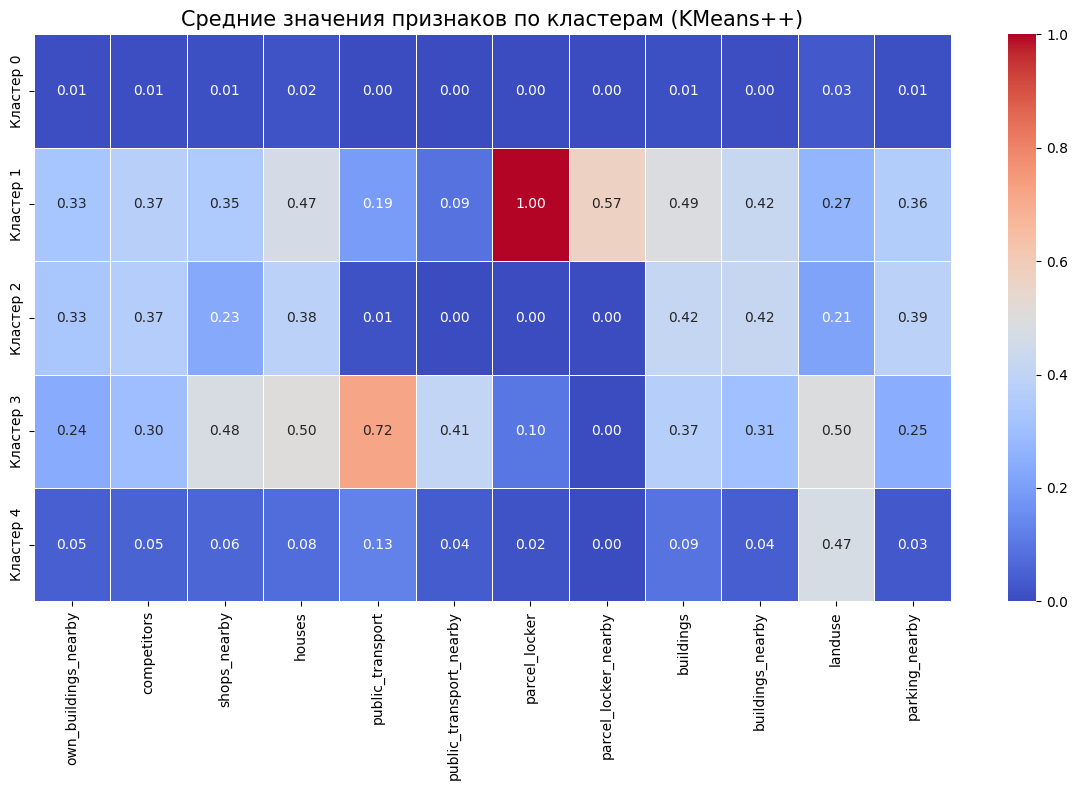

In [74]:
X_clust_df['index_score'] = y
X_clust_df.groupby('cluster')['index_score'].describe()

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = X[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=features
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans++)', fontsize=15)
plt.tight_layout()
plt.show()

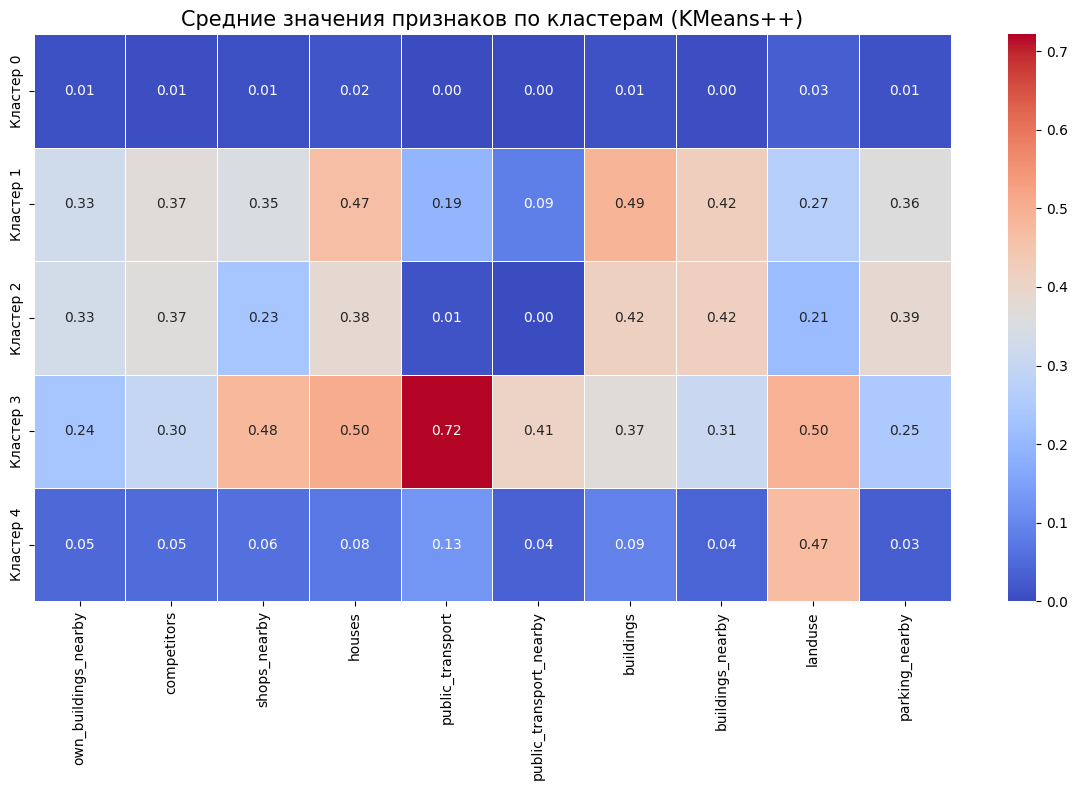

In [75]:
feat_no_pl= ['own_buildings_nearby', 'competitors', 'shops_nearby', 'houses',
             'public_transport', 'public_transport_nearby', 'buildings',
             'buildings_nearby', 'landuse', 'parking_nearby']
no_pl_df = X_clust_df.copy()
no_pl_df = no_pl_df[feat_no_pl]

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = no_pl_df[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=feat_no_pl
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans++)', fontsize=15)
plt.tight_layout()
plt.show()

### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции

уже сделано ранее

- Рассчитайте итоговый потенциал для всех ячеек сетки
- Категоризируйте потенциал для упрощения интерпретации результатов

Потенциал будем рассматривать следующим образом:

- 0.9-1.0 - самое рекомендуемое место (5)
- 0.8-0.9 - может подойти для открытия, на "втором плане" (4)
- 0.7-0.8 - есть возможности для открытия, но не особо рекомендуемые (3)
- 0.5-0.7 - в основном, нежилые места, или места, где недостаточно потенциала для открытия (2)
- 0.0-0.5 - места, в которых уже есть открытые ПВЗ, или высока конкурентность. не рекомендуется (1)

   - Обоснуйте выбранные веса в контексте вашего бизнеса

уже сделано ранее

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса

In [76]:
clust_gdf = main_gdf.copy()
clust_gdf['index_score'] = y
clust_gdf['cluster'] = X_clust_df['cluster'].astype(str)
bins = [0.0, 0.5, 0.7, 0.8, 0.9, 1.0]

labels = ['1', '2', '3', '4', '5']

clust_gdf['cat'] = pd.cut(
    clust_gdf['index_score'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
).astype(str)

m4 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m4.add_data(
    clust_gdf,
    column="cat",
    cmap="OrRd",
    legend_title="cat",
    layer_name="H3 Сетка",
    scheme='EqualInterval',
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m4.add_gdf(ozon_gdf, layer_name='OZON Location', info_mode='on_click')
m4

Map(center=[np.float64(55.54351235), np.float64(38.258448200000004)], controls=(ZoomControl(options=['position…

   - Выделите топ-10 локаций с наивысшим потенциалом

In [77]:
best_gdf = clust_gdf.sort_values('index_score', ascending=False).head(10)
best_gdf

,h3_index,geometry,own_buildings_nearby,competitors,shops_nearby,houses,public_transport,public_transport_nearby,parcel_locker,parcel_locker_nearby,buildings,buildings_nearby,landuse,parking_nearby,index_score,cluster,cat
643,89118cd81a7ffff,"POLYGON ((4255342.9 7471676.609, 4255607.312 7...",0.000000,0.2,0.2,0.255102,1.000000,0.428571,1.0,1.0,0.1,0.166667,0.627119,0.342857,1.000000,1,5
424,89118cd8cd3ffff,"POLYGON ((4255695.427 7472181.73, 4255959.852 ...",0.428571,0.4,1.0,0.642857,1.000000,0.285714,1.0,1.0,0.7,0.666667,0.423729,0.628571,0.988921,1,5
635,89118cd8cdbffff,"POLYGON ((4255915.781 7471612.556, 4256180.187...",0.142857,0.4,0.2,0.510204,1.000000,0.714286,1.0,1.0,0.4,0.333333,0.576271,0.228571,0.949843,1,5
68,89118cd8ccbffff,"POLYGON ((4256488.678 7471548.459, 4256753.077...",0.000000,0.2,0.2,0.622449,0.714286,0.714286,1.0,0.0,0.5,0.166667,0.440678,0.171429,0.941263,3,5
40,89118cd8537ffff,"POLYGON ((4252126.485 7471491.006, 4252390.911...",0.000000,0.0,0.6,0.357143,0.428571,0.285714,0.0,0.0,0.2,0.333333,0.559322,0.085714,0.898526,3,4
30,89118cdaacbffff,"POLYGON ((4252478.721 7471996.201, 4252743.161...",0.000000,0.4,0.6,0.653061,0.714286,0.142857,0.0,0.0,0.2,0.333333,0.745763,0.114286,0.894369,3,4
373,89118cd8cb3ffff,"POLYGON ((4256885.698 7474771.86, 4257150.2 74...",0.285714,0.2,0.7,0.551020,0.000000,0.000000,1.0,1.0,0.3,0.333333,0.288136,0.514286,0.888779,1,4
227,89118cda877ffff,"POLYGON ((4253137.806 7477369.084, 4253402.416...",0.142857,0.2,0.4,0.530612,0.000000,0.000000,1.0,1.0,0.3,0.333333,0.135593,0.142857,0.874971,1,4
124,89118cdaa03ffff,"POLYGON ((4253535.746 7473511.944, 4253800.229...",0.142857,0.0,0.5,0.306122,0.428571,0.142857,1.0,0.0,0.4,0.500000,0.271186,0.400000,0.862299,1,4
577,89118cd81b7ffff,"POLYGON ((4254770.034 7471740.617, 4255034.452...",0.000000,0.0,0.2,0.071429,1.000000,1.000000,0.0,0.0,0.2,0.000000,0.576271,0.285714,0.844196,3,4


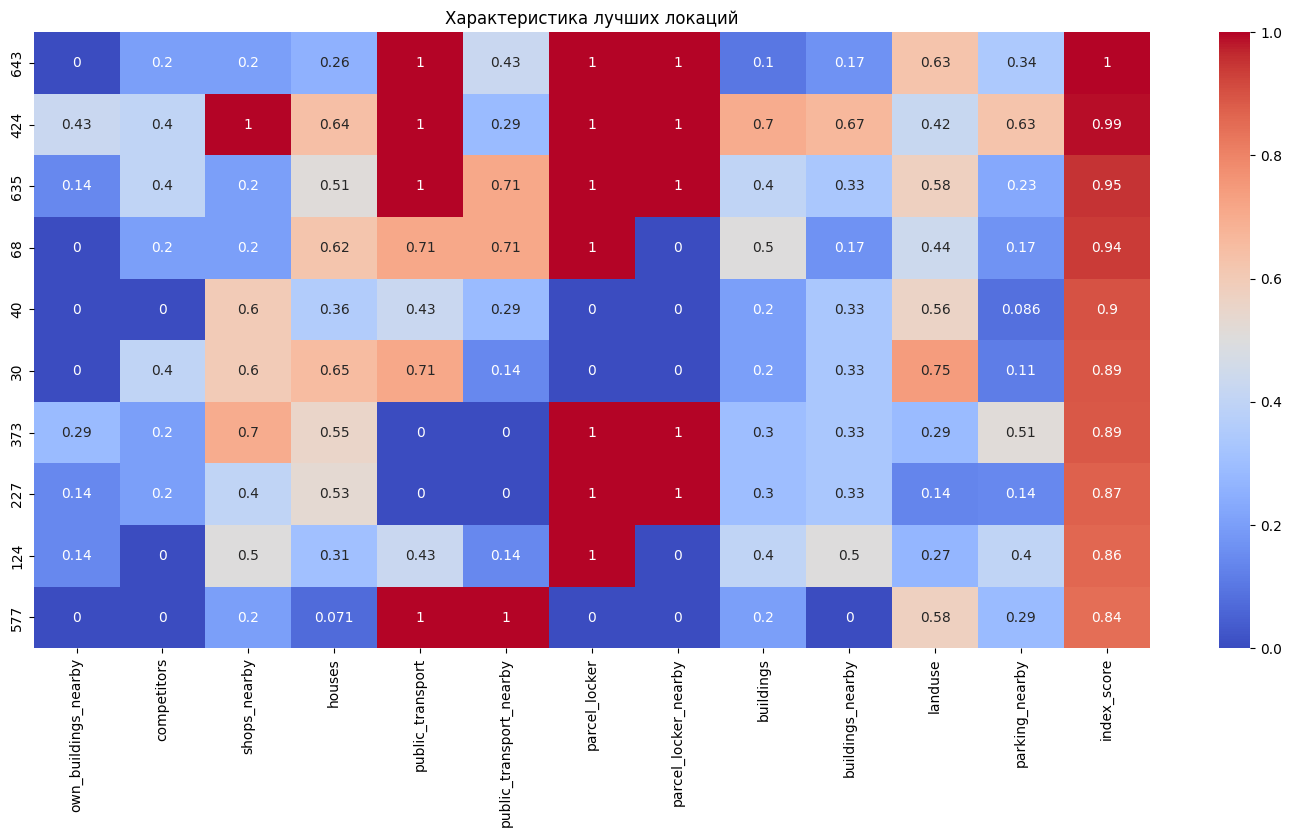

In [78]:
fin_feat = features.copy()
fin_feat.append('index_score')

plt.figure(figsize=(18, 8))
sns.heatmap(best_gdf[fin_feat], annot=True, cmap='coolwarm')
plt.title('Характеристика лучших локаций')
plt.show()

   - Подготовьте отдельную карту фокуса на лучших локациях

In [80]:
m5 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

data = []
for h3_id in best_gdf['h3_index']:
    lat, lng = h3.h3_to_geo(h3_id)
    data.append({'h3_id': h3_id, 'lat': lat, 'lng': lng})

df_centers = pd.DataFrame(data)
gdf_centers = gpd.GeoDataFrame(
    df_centers,
    geometry=gpd.points_from_xy(df_centers['lng'], df_centers['lat']),
    crs="EPSG:4326"  # WGS 84 coordinate system
)

m5.add_gdf(
    gdf_centers,
    layer_name="best points",
    info_mode='on_click'
)

m5.add_data(
    best_gdf,
    column='index_score',
    cmap="Greens",
    k=11,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m5

Map(center=[np.float64(55.54351235), np.float64(38.258448200000004)], controls=(ZoomControl(options=['position…

3. **Формирование бизнес-рекомендаций**:
    - Составьте список из 5-7 конкретных локаций для размещения новых объектов
    - Для каждой рекомендуемой локации укажите:
      * Точные координаты
      * Значение потенциала
      * Ключевые характеристики локации
      * Преимущества и возможные риски размещения в данной точке

Адрес и координаты будут выбираться примерно близкими к выбранным ячейкам

|Номер|Коорд-ты|Адрес|Index Score|Хар-ки|Преимущества и риски|
|-|-|-|-|-|-|
|1|4255342.9 7471676.609|Раменское, улица Евсеева|1.00|Поблизости присутствуют:<br> одна из главных остановок публичного транспорта;<br>Вблизи достаточно жилых домов;<br>Расположение вблизи одной из главных станций в городе на МЦД3|**Плюсы**: Много людей днём (офисы + спорт),<br> хорошая видимость из-за открытых участков<br><br>**Риски**: Столпотворение, мало парковочных мест,<br> возможна высокая аренда|
|2|4255695.427 7472181.73|Раменское, улица Гурьева|0.98|Так же находится близко к высокопроходимой части города;<br>Находится близости к станции на МЦД3;<br>Близко находятся станции общественного транпорта, школа, один из главных торговыъ центров поблизости|**Плюсы**: Много потенциальных клиентов из людей, идущих со станций или в школу за ребёнком или в ТЦ,<br> удобно для доставки ввиду широкой дороги<br><br>**Риски**: Потенциальные пробки в течении дня из-за большой проходимости,<br> возможен шум от дороги|
|3|4255915.781 7471612.556|Раменское, улица Бронницкая|0.94|Прямая близость со станцией на МЦД3 и автобусными станциями;<br>Наличие парковки;<br>Достаточное кол-во магазинов поблизости|**Плюсы**: Отличная доступность на транспорте,<br> высокий поток пассажиров, удобно забирать по пути<br><br>**Риски**: Может быть людно и шумно,<br> аренда рядом с вокзалом часто дороже|
|4|4256488.678 7471548.459|Раменское, улица Красная|0.94|Поблизости много жилых домов;<br>Расположение внутри жилого комплекса;<br>Рядом есть автобусная остановка, близость к станции;<br>Вблизи расположены дет.сады, школы и другие магазины|**Плюсы**: Новые жители = новые клиенты, «своя» аудитория внутри ЖК<br><br>**Риски**: Зависимость от заселения ЖК, шум от близлежащей жд|
|5|4252126.485 7471491.006|Раменское, улица Серова|0.89|Доступ к общественному транспорту;<br>Нахождение вблизи заселённых домов, одного из больших супермаркетов в городе;<br>Наличие большого числа парковок поблизости;<br>Наличие в ближайшем радиусе школ, их отделений и дет.садов|**Плюсы**: Одна из самых обжитых точек, много семей с детьми,<br> удобно заезжать на машине<br><br>**Риски**: Рядом уже есть постамат - часть клиентов уже обслуживается,<br> возможна конкуренция за трафик|

In [81]:
m6 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

coords = np.array([
    [55.417848, 37.520806],
    [55.364118, 37.533149],
    [55.357695, 37.527516],
    [55.417807, 37.541216],
    [55.469362, 37.546426]
])

points_gdf = gpd.GeoDataFrame(
    {'lat': coords[:, 0], 'lon': coords[:, 1]},
    geometry=gpd.points_from_xy(coords[:, 1], coords[:, 0]),
    crs="EPSG:4326"
)

m6.add_gdf(
    points_gdf,
    layer_name="best points",
    info_mode='on_click'
)

m6.add_data(
    best_gdf.head(5),
    column='index_score',
    cmap="Greens",
    k=6,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m6

Map(center=[np.float64(55.54351235), np.float64(38.258448200000004)], controls=(ZoomControl(options=['position…

   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

1. Необходимо открываться рядом с жилыми домами, в густонаселённых районах.
2. Избегать прямой конкуренции, не открывать новый пункт рядом с уже работающими ПВЗ (своими или конкурентов).
3. Необходимо учитывать трафик - открываться рядом с остановками, магазинами, школами, ведь так людям удобнее заходить по пути.
4. Учитывать парковку, ведь она является плюсом для клиентов с крупными заказами.
5. Лучше начинать с малого, сначала покрывать районы, где вообще нет ПВЗ, потом уже переходить на более крупные.

## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.